# Masking the VLA-ANGST H I Spectral Cube of NGC 3741
---
## 2.1 Aim
This notebook constructs a three-dimensional signal mask for the natural-weighted VLA-ANGST H I cube of NGC 3741 from the survey of Ott et al. (2012). The mask is designed to retain spatially and spectrally connected emission representing the dwarf galaxy's extended H I disk structure and reject background noise before the cube is exported for three-dimensional visualization.

**Procedure:**
> 1. Spatially crop the cube
> 2. Use a preliminary spectrum to crop its velocity range
> 3. Create spatially + spectrally smoothed cube
> 4. Estimate bg noise for each channel
> 5. Create and grow a two-threshold mask (6σ/5σ)
> 9. Remove small detections
> 10. Apply the mask to the original spatially and velocity cropped cube
> 11. Check then export the products

## 2.2 Setup and data loading
All imports are collected here so the notebook may be run sequentially from a fresh kernel. The VLA-ANGST H I cube is expected in the same directory as the notebook.
<div class="alert alert-info"> When the file is opened, `spectral_cube` may report that it has selected the Stokes I component. Stokes I represents total intensity and is the appropriate component for this analysis. </div>

In [1]:
from pathlib import Path

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.convolution import Box1DKernel
from astropy.io import fits
from astropy.stats import mad_std
from astropy.wcs.utils import proj_plane_pixel_scales
from radio_beam import Beam
from scipy.ndimage import (
    binary_propagation,
    generate_binary_structure,
    label,
)
from spectral_cube import SpectralCube

In [2]:
dataPath = Path("VlA-ANGST_HI_NGC3741-nat-cube.fits.gz")
cube = SpectralCube.read(dataPath)

print(cube)

SpectralCube with shape=(115, 1024, 1024) and unit=Jy / beam:
 n_x:   1024  type_x: RA---SIN  unit_x: deg    range:   173.721486 deg:  174.329586 deg
 n_y:   1024  type_y: DEC--SIN  unit_y: deg    range:    45.069878 deg:   45.496127 deg
 n_s:    115  type_s: VOPT-F2W  unit_s: m / s  range:   154187.126 m / s:  301268.539 m / s


## 2.3 Spatial cropping
As observed in the initial inspection of the data cube, the full cube contains a large region without visible galaxy emission. Spatially cropping the cube reduces irrelevant computation and will help produce a cleaner product in Blender.

For intensity $I(x,y,v_k)$ in velocity channel $k$, the displayed value is

$$
I_{\mathrm{peak}}(x,y)=\max_k I(x,y,v_k).
$$

This is implemented by `cube.max(axis=0)`, because axis 0 is the spectral axis. 

In [3]:
# find the brightest value along the spectral(velocity) axis at each spatial pixel
cubeMaxVals = cube.max(axis=0, how='slice')
cubeMapVals = cubeMaxVals.value

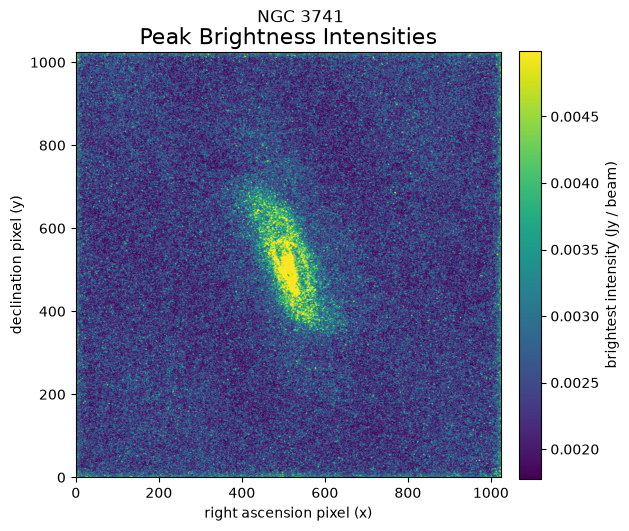

In [4]:
fig = plt.figure(figsize=(6,7), dpi=100.0)
fig.suptitle('NGC 3741', y=0.86, fontsize=12)

plt.imshow(cubeMapVals, cmap='viridis', vmin=np.nanpercentile(cubeMapVals, 5), vmax=np.nanpercentile(cubeMapVals, 99.5), origin='lower')
plt.colorbar(label=f"brightest intensity ({cube.unit})", fraction=0.046, pad=0.04)
plt.xlabel("right ascension pixel (x)")
plt.ylabel("declination pixel (y)")
plt.title("Peak Brightness Intensities", fontsize=16, fontweight='400')

plt.show()

In [5]:
# estimated spatial boundaries for data masking, specified as cube[velocity, y, x].
x_min, x_max = 300, 700
y_min, y_max = 300, 800

# spatially crop the cube
cubeCropped = cube[:, y_min:y_max, x_min:x_max]

print("Original shape:", cube.shape)
print("Spatially cropped shape", cubeCropped.shape)

Original shape: (115, 1024, 1024)
Spatially cropped shape (115, 500, 400)


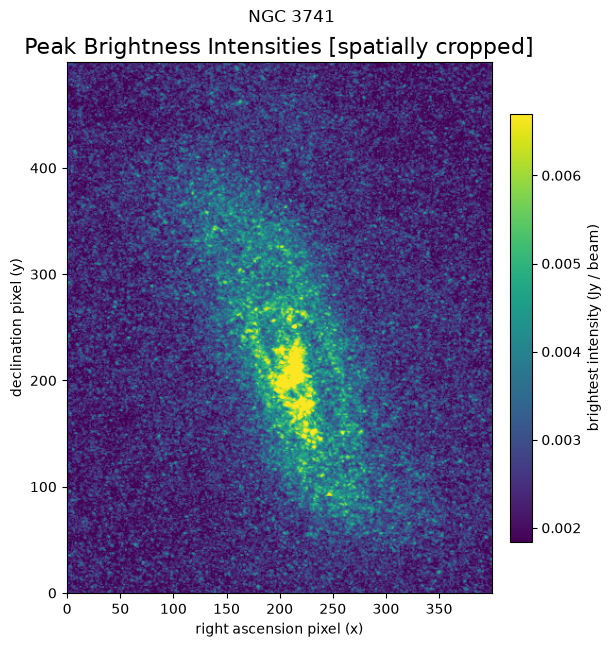

In [6]:
#plot for viz of spatially cropped cube
#revised vals
cubeMaxValsCropped = cubeCropped.max(axis=0, how='slice')
cubeMapValsCropped = cubeMaxValsCropped.value

fig = plt.figure(figsize=(6,7), dpi=100.0)
fig.suptitle('NGC 3741', y=0.95, fontsize=12)

plt.imshow(cubeMapValsCropped, cmap='viridis', vmin=np.nanpercentile(cubeMapValsCropped, 5), vmax=np.nanpercentile(cubeMapValsCropped, 99.5), origin='lower')
plt.colorbar(label=f"brightest intensity ({cube.unit})", fraction=0.046, pad=0.04)
plt.xlabel("right ascension pixel (x)")
plt.ylabel("declination pixel (y)")
plt.title("Peak Brightness Intensities [spatially cropped]", fontsize=16, fontweight='400')
plt.show()

## 2.4 Preliminary spectrum and velocity-range estimation  
Before masking, I averaged the intensity (Jy beam$^{-1}$) across the spatially cropped cube. This preliminary average H I spectrum for NGC 3741, however, cannot be used to measure the galaxy's total H I flux as significant background noise is present as galaxy emission is not properly isolated.

For a channel containing $N_{xy}$ valid spatial pixels, `cubeCropped.mean(axis=(1, 2))` calculates

$$
\bar I(v_k)=\frac{1}{N_{xy}}\sum_{x,y} I(x,y,v_k).
$$

The result remains a mean brightness in Jy beam$^{-1}$ rather than spatially integrated flux density in Jy. Such spectrum is calculated in a later section (2.4.2) after the final mask is applied to the cube.

I use this preliminary spectrum to choose an approximate velocity crop: the spectrum suggests detectable emission of range 170-290 km/s. I therefore retain velocity channels approximately within the range of 165-295 km/s to avoid the exclusion of faint emission near the boundaries. 

In [7]:
# collapse spatial axes, create avgSpectrum array with mean brightness values
avgSpectrum = cubeCropped.mean(axis=(1,2), how='slice') 
# convert the cube's spectral coordinates into numerical velocities in km/s
velocities = cubeCropped.spectral_axis.to_value(u.km / u.s)

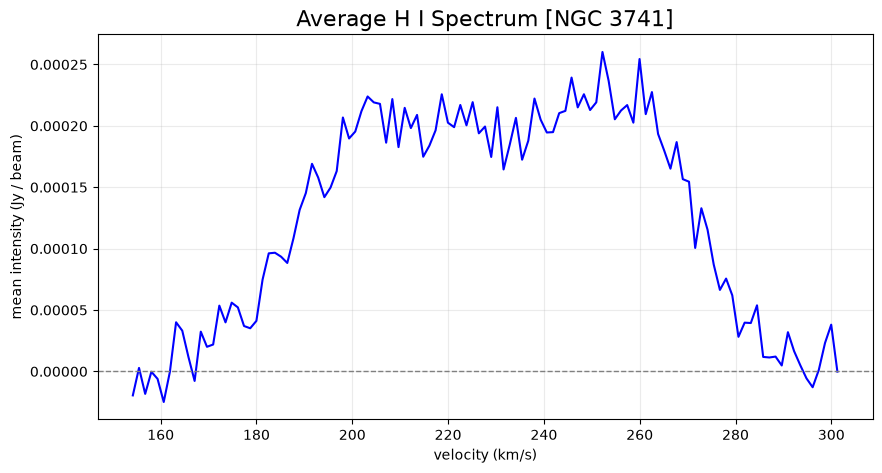

In [8]:
plt.figure(figsize=(10,5))
plt.plot(velocities, avgSpectrum.value, color='blue', linewidth=1.5)
plt.axhline(y=0, color='gray', linestyle='--', linewidth=1)

plt.xlabel("velocity (km/s)")
plt.ylabel(f"mean intensity ({avgSpectrum.unit})")
plt.title("Average H I Spectrum [NGC 3741]", fontsize=16, fontweight=400)
plt.grid(alpha=0.25)
plt.show()

In [9]:
# velocity crop 
vMin = 165 * u.km / u.s
vMax = 295 * u.km / u.s

# spectrally crop the cube
cubeVelocityCrop = cubeCropped.spectral_slab(vMin, vMax)

print("Original shape:", cube.shape)
print("Velocity cropped shape", cubeVelocityCrop.shape)

print("Retained velocity range:", cubeVelocityCrop.spectral_axis[0].to(u.km / u.s),
      "To:", cubeVelocityCrop.spectral_axis[-1].to(u.km / u.s))

Original shape: (115, 1024, 1024)
Velocity cropped shape (102, 500, 400)
Retained velocity range: 164.50392515172268 km / s To: 294.81457583187955 km / s


## 2.5 Three-dimensional mask generation  
The mask is derived from a smoothed copy of the cropped cube, so coherent emission may be easily distinguished from noise. The completed Boolean mask is applied to `cubeVelocityCrop` to create a final mask.  

### 2.5.1 Robust MAD channel-wise
The noise level is estimated independently in every velocity channel via four 50x50 pixel corner regions. These regions were selected as they are assumed to be outside visible galaxy emission.  
Their pixels are flattened and concatenated into one background sample $B_k$ for each channel $k$. 

`astropy.stats.mad_std` estimates the standard deviation using the median absolute deviation (MAD):  
$$
\operatorname{MAD}_k=\operatorname{median}_{i}\left|B_{k,i}-\operatorname{median}_{j}(B_{k,j})\right|,
$$

$$
\sigma_k \approx 1.4826\,\operatorname{MAD}_k.
$$

The factor of 1.4826 makes the estimator comparable to the ordinary standard deviation for normally distributed noise. This method is more resistant to bright outliers than calculating $\sqrt{\frac{1}{N}\sum_i(B_{k,i}-\bar B_k)^2}$ directly! Although the quantity is described here as the background RMS, the code actually estimates the spread $\sigma_k$ of the channel background rather than the mean background level. But, for approximately zero-centered Gaussian-distributed noise, it can be used as an RMS noise amplitude. 

In [10]:
def estimateCornerRms(dataCube, cornerSz=50):
    # estimate channel-wise RMS noise from the four spatial corners.
    corners = [
        dataCube[:, :cornerSz, :cornerSz],
        dataCube[:, :cornerSz, -cornerSz:],
        dataCube[:, -cornerSz:, :cornerSz],
        dataCube[:, -cornerSz:, -cornerSz:],
    ]

    cornerArrays = []
    for corner in corners:
        cornerVals = corner.unmasked_data[:].value
        cornerArrays.append(cornerVals.reshape(cornerVals.shape[0], -1))

    backgroundVals = np.concatenate(cornerArrays, axis=1)
    channelRms = mad_std(backgroundVals, axis=1, ignore_nan=True)
    return channelRms

### 2.5.2 Spatial and Spectral Smoothing
The cube is convolved spatially to twice the original beam dimensions and smoothed across three adjacent velocity channels. For Gaussian beams, `convolve_to` determines a convolution kernel whose covariance satisfies:

$$
\boldsymbol{\Sigma}_{\mathrm{kernel}}
=\boldsymbol{\Sigma}_{\mathrm{target}}
-\boldsymbol{\Sigma}_{\mathrm{original}}
$$

Therefore, convolving the original beam with this kernel produces the requested target beam. The subsequent three-channel boxcar kernel calculates approximately:

$$
I_{\mathrm{smooth}}(x,y,v_k)
=\frac{I_{\mathrm{spatial}}(x,y,v_{k-1})
+I_{\mathrm{spatial}}(x,y,v_k)
+I_{\mathrm{spatial}}(x,y,v_{k+1})}{3}
$$

Both of the operations suppress negligent noise and favor emission that is coherent across neighboring space and velocities. The smoothed cube is used to construct the mask as I use the intensity values of the original cropped cube for the final cube mask.

In [11]:
# beam output of radio telescope survey: BMAJ (length of beam's long axis), BMIN (length of short axis), BPA (angle at which the elliptical beam is rotated)
print(cubeVelocityCrop.beam)

Beam: BMAJ=7.64352 arcsec BMIN=6.20352 arcsec BPA=81.1 deg


In [12]:
originalBeam = cubeVelocityCrop.beam
velocitiesCrop = cubeVelocityCrop.spectral_axis.to_value(u.km / u.s)
targetBeam = Beam( # spatial smoothing to twice the original beam size
    major=2 * originalBeam.major,
    minor=2 * originalBeam.minor,
    pa=originalBeam.pa,
)

spatialSmoothCube = cubeVelocityCrop.convolve_to(targetBeam)
spectralKernel = Box1DKernel(3) 
smoothCube = spatialSmoothCube.spectral_smooth(spectralKernel)

print("Original beam:", originalBeam)
print("Target beam:", targetBeam)
print("Before smoothing:", cubeVelocityCrop.shape)
print("After smoothing:", smoothCube.shape)

Original beam: Beam: BMAJ=7.64352 arcsec BMIN=6.20352 arcsec BPA=81.1 deg
Target beam: Beam: BMAJ=15.28704 arcsec BMIN=12.40704 arcsec BPA=81.1 deg
Before smoothing: (102, 500, 400)
After smoothing: (102, 500, 400)


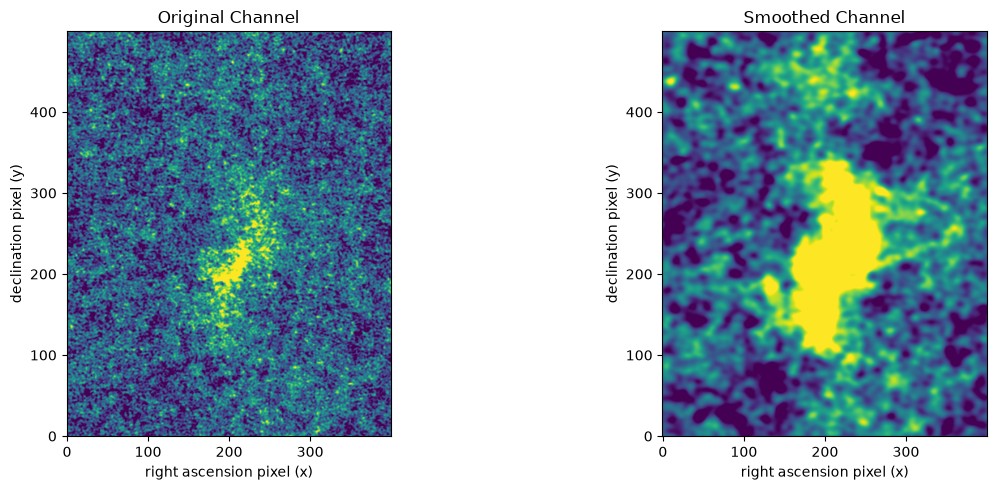

Displayed velocity: 252.2253771466788 km / s
Peak channel: 68


In [13]:
# compare before and after smoothing
# inspect the channel with the highest spatially averaged intensity
testSpec = cubeVelocityCrop.mean(axis=(1,2), how='slice')
peakChannel = int(np.nanargmax(testSpec.value))

ogImg = cubeVelocityCrop[50].value
smImg = smoothCube[50].value

displayMin = np.nanpercentile(ogImg, 5)
displayMax = np.nanpercentile(ogImg, 99.5)

fig, axes = plt.subplots(1, 2, figsize=(13,5))
for a in axes:
    a.set_xlabel("right ascension pixel (x)")
    a.set_ylabel("declination pixel (y)")

axes[0].imshow(ogImg, origin='lower', cmap='viridis', vmin=displayMin, vmax=displayMax)
axes[0].set_title("Original Channel")

axes[1].imshow(smImg, origin='lower', cmap='viridis', vmin=displayMin, vmax=displayMax)
axes[1].set_title("Smoothed Channel")

plt.tight_layout()
plt.show()

print("Displayed velocity:", cubeVelocityCrop.spectral_axis[peakChannel].to(u.km / u.s))
print("Peak channel:", peakChannel)

### 2.5.3 Noise before and after smoothing

Smoothing changes both the noise distribution and the effective beam. Therefore, a threshold applied to `smoothCube` must use noise measured from that same smoothed cube.
The same function and corner geometry are applied to both cubes. `originalRmsPerChannel` is used as a base-line for seeing how smoothing may change the channel noise. `smoothRmsPerChannel` represents the detection cube and is the noise array used to construct the mask.

original median RMS: 0.000923 Jy / beam
smoothed median RMS: 0.001003 Jy / beam


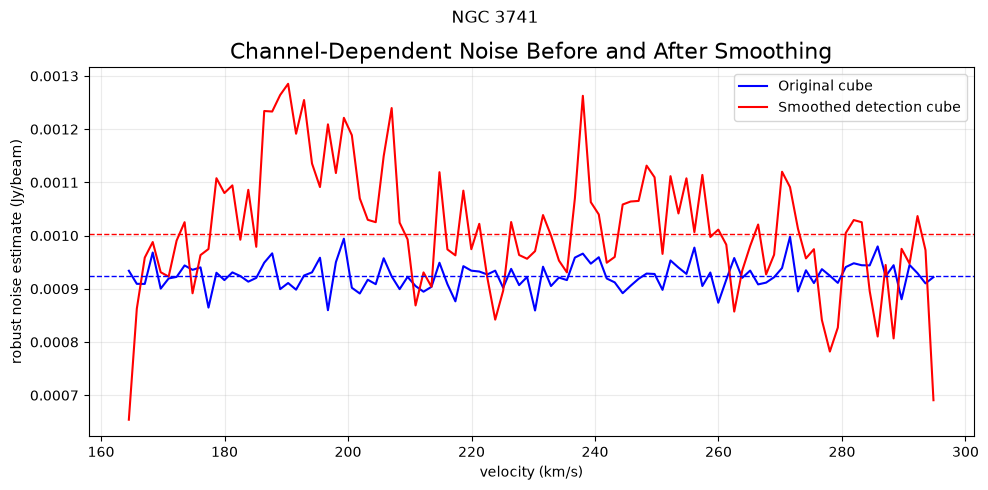

In [14]:
originalRmsPerChannel = estimateCornerRms(cubeVelocityCrop)
smoothRmsPerChannel = estimateCornerRms(smoothCube)

originalMedianRms = np.nanmedian(originalRmsPerChannel)
smoothMedianRms = np.nanmedian(smoothRmsPerChannel)

print(f"original median RMS: {originalMedianRms:.6f} {cubeVelocityCrop.unit}")
print(f"smoothed median RMS: {smoothMedianRms:.6f} {smoothCube.unit}")

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("NGC 3741", y=0.97, fontsize=12)

ax.plot(velocitiesCrop, originalRmsPerChannel, color="blue", linewidth=1.5, label="Original cube")
ax.plot(velocitiesCrop, smoothRmsPerChannel, color="red", linewidth=1.5, label="Smoothed detection cube")

ax.axhline(originalMedianRms, color="blue", linestyle="--", linewidth=1)
ax.axhline(smoothMedianRms, color="red", linestyle="--", linewidth=1)
ax.set_xlabel("velocity (km/s)")
ax.set_ylabel("robust noise estimate (Jy/beam)")
ax.set_title("Channel-Dependent Noise Before and After Smoothing", fontsize=16)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()

### 2.5.4 Two-threshold signal mask

Two preliminary masks are generated from the smoothed cube. Voxels above $6\sigma$ form reliable "seed" regions - each seed can expand through connected voxels above $5\sigma$.

For every voxel $(x,y,k)$, the two Boolean masks can be represented by:

$$
M_{\mathrm{strong}}(x,y,k)=
\begin{cases}
1, & I_{\mathrm{smooth}}(x,y,k)>6\sigma_{k,\mathrm{smooth}},\\
0, & \text{otherwise},
\end{cases}
$$

$$
M_{\mathrm{weak}}(x,y,k)=
\begin{cases}
1, & I_{\mathrm{smooth}}(x,y,k)>5\sigma_{k,\mathrm{smooth}},\\
0, & \text{otherwise}.
\end{cases}
$$

The reshaped `noiseCube` has dimensions $(N_v,1,1)$, so NumPy broadcasting compares every spatial pixel in channel $k$ with that channel's own noise estimate. Only positive H I emission is selected.

`binary_propagation` defines the grown mask as the subset of $M_{\mathrm{weak}}$ that is connected to at least one voxel in $M_{\mathrm{strong}}$. With `connectivity=1`, two voxels are neighbors only when they share a face along $x$, $y$, or velocity. Therefore, a weak voxel is retained only if a six-connected path through other weak voxels reaches a strong "seed".

In [15]:
# create strong and weak masks
smoothData = smoothCube.unmasked_data[:].value #load smoothed data
noiseCube = smoothRmsPerChannel[:, np.newaxis, np.newaxis] #reshape noise arry so each channel uses its own RMS

# create thresholds
strongSigma = 6
weakSigma = 5

strongMask = smoothData > (strongSigma * noiseCube)
weakMask = smoothData > (weakSigma * noiseCube)

print("Strong-mask voxels:", np.count_nonzero(strongMask))
print("Weak-mask voxels:", np.count_nonzero(weakMask))

Strong-mask voxels: 486382
Weak-mask voxels: 676224


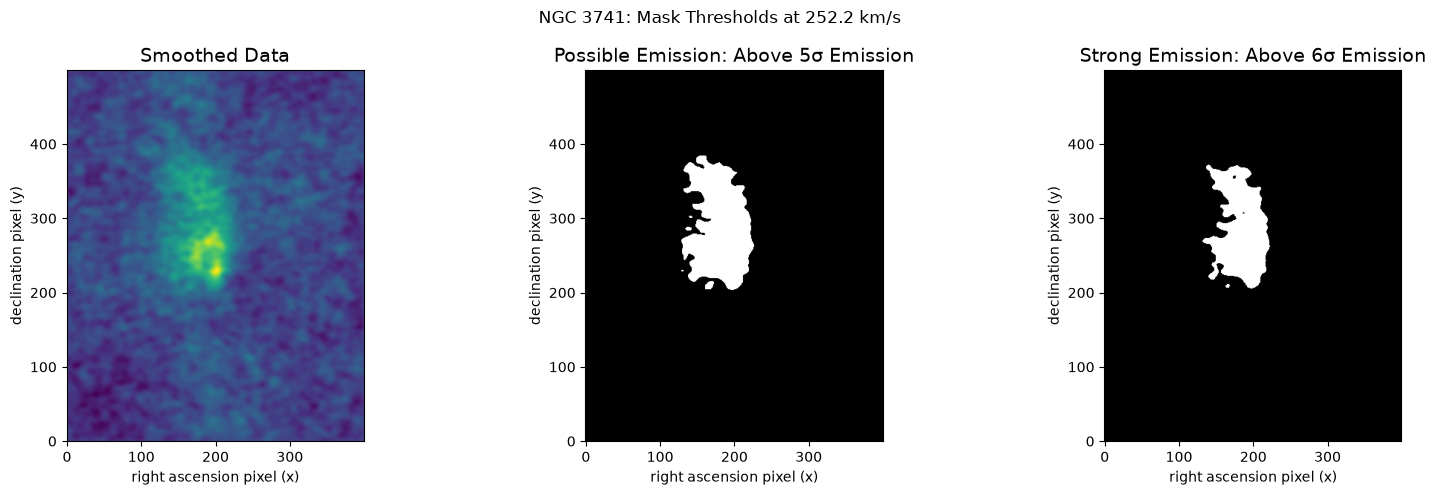

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
fig.suptitle(f"NGC 3741: Mask Thresholds at {velocitiesCrop[peakChannel]:.1f} km/s", fontsize = 12)

for a in axes:
    a.set_xlabel("right ascension pixel (x)")
    a.set_ylabel("declination pixel (y)")

axes[0].imshow(smoothData[peakChannel], origin='lower')
axes[0].set_title("Smoothed Data", fontsize=14)

axes[1].imshow(weakMask[peakChannel], origin='lower', cmap='bone')
axes[1].set_title(f"Possible Emission: Above {weakSigma}σ Emission", fontsize=14)

axes[2].imshow(strongMask[peakChannel], origin='lower', cmap='bone')
axes[2].set_title(f"Strong Emission: Above {strongSigma}σ Emission", fontsize=14)

plt.tight_layout()
plt.show()

In [17]:
# voxels can connect through position/neighboring velocity channels
connectionStruc = generate_binary_structure(rank=3, connectivity=1)

grownMask = binary_propagation(
    strongMask, 
    structure=connectionStruc,
    mask=weakMask
)

print("Strong-mask voxels:", np.count_nonzero(strongMask))
print("Grown-mask voxels:", np.count_nonzero(grownMask))

Strong-mask voxels: 486382
Grown-mask voxels: 674282


### 2.5.5 Removal of small detections

Connected components smaller than approximately one smoothed beam across three velocity channels are removed. For an elliptical Gaussian beam with full widths at half maximum $\theta_{\mathrm{maj}}$ and $\theta_{\mathrm{min}}$, the beam solid angle is:

$$
\Omega_{\mathrm{beam}}
=\frac{\pi}{4\ln 2}\,\theta_{\mathrm{maj}}\theta_{\mathrm{min}}
\approx1.1331\,\theta_{\mathrm{maj}}\theta_{\mathrm{min}}.
$$

If the celestial pixel scales are $\Delta\theta_x$ and $\Delta\theta_y$, then:

$$
A_{\mathrm{pixel}}=|\Delta\theta_x\Delta\theta_y|,
\qquad
N_{\mathrm{pix/beam}}=\frac{\Omega_{\mathrm{beam}}}{A_{\mathrm{pixel}}}.
$$

The adopted minimum connected-component size is:

$$
N_{\mathrm{min}}=\left\lceil 3N_{\mathrm{pix/beam}}\right\rceil.
$$

...Which corresponds approximately to one smoothed beam sustained across three channels. 

`scipy.ndimage.label` assigns a NUM to every connected component and `np.bincount` measures its voxels.

In [18]:
# remove small isolated detections from noise spikes
# by removing objs smaller than ~1 beam across 2 velocity channels
# calculate how many pixels fit inside 1 beam
pixelScales = (proj_plane_pixel_scales(smoothCube.wcs.celestial)*u.deg)

pixelArea = abs(pixelScales[0]*pixelScales[1])
beamArea = smoothCube.beam.sr.to(u.deg**2)

pixelsPerBeam = (beamArea / pixelArea).decompose().value

# requires a detection to cover about 1 beam across 2 channels
minVoxs = int(np.ceil(3*pixelsPerBeam))

print("Pixels per beam:", round(pixelsPerBeam, 1))
print("Minimum object size:", minVoxs, "voxels")

Pixels per beam: 95.5
Minimum object size: 287 voxels


In [19]:
# label & remove small noise spikes
labeledMask, numOfObjs = label(grownMask, structure=connectionStruc)
objSizes = np.bincount(labeledMask.ravel())

objToKeep = objSizes >= minVoxs
objToKeep[0] = False # label 0 = the background

cleanMask = objToKeep[labeledMask]

print("Objects before cleanup:", numOfObjs)
print("Retained objects:", np.count_nonzero(objToKeep))
print("Final retained voxels:", np.count_nonzero(cleanMask))

Objects before cleanup: 11
Retained objects: 2
Final retained voxels: 673200


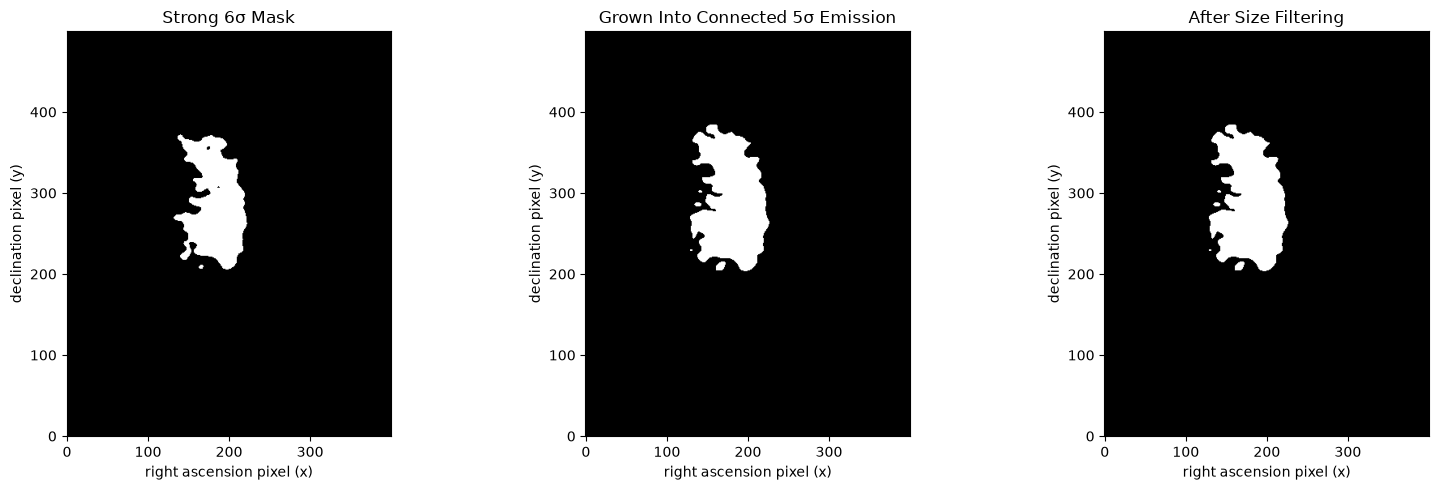

In [20]:
# plot for visualization and inspection of results
fig, axes = plt.subplots(1, 3, figsize=(16,5))
for a in axes:
    a.set_xlabel("right ascension pixel (x)")
    a.set_ylabel("declination pixel (y)")

axes[0].imshow(strongMask[peakChannel], origin='lower', cmap='bone')
axes[0].set_title(f"Strong {strongSigma}σ Mask")

axes[1].imshow(grownMask[peakChannel], origin='lower', cmap='bone')
axes[1].set_title(f"Grown Into Connected {weakSigma}σ Emission")

axes[2].imshow(cleanMask[peakChannel], origin='lower', cmap='bone')
axes[2].set_title("After Size Filtering")

plt.tight_layout()
plt.show()

## 2.6. Application and creating data products

The cleaned Boolean mask has the same shape as the cropped cube.

$$
I_{\mathrm{masked}}(x,y,k)=
\begin{cases}
I_{\mathrm{original}}(x,y,k), & M_{\mathrm{final}}(x,y,k)=1,\\
\text{blank}, & M_{\mathrm{final}}(x,y,k)=0.
\end{cases}
$$

`with_mask` stores rejected voxels as invalid. The original cube's values are retained wherever the mask is true - hence, the mask concept.

In [21]:
# create final mask
finalMask = cleanMask.astype(bool)

# apply to original cube
finalMaskedCube = cubeVelocityCrop.with_mask(finalMask) 
print(finalMaskedCube)

print("Cube shape:", cubeVelocityCrop.shape)
print("Mask shape:", finalMask.shape)
print("Retained voxels:", np.count_nonzero(finalMask))
print("Retained %:", 100*np.count_nonzero(finalMask) / finalMask.size)

SpectralCube with shape=(102, 500, 400) and unit=Jy / beam:
 n_x:    400  type_x: RA---SIN  unit_x: deg    range:   173.914265 deg:  174.151050 deg
 n_y:    500  type_y: DEC--SIN  unit_y: deg    range:    45.195210 deg:   45.403140 deg
 n_s:    102  type_s: VOPT-F2W  unit_s: m / s  range:   164503.925 m / s:  294814.576 m / s
Cube shape: (102, 500, 400)
Mask shape: (102, 500, 400)
Retained voxels: 673200
Retained %: 3.3


### 2.6.1 Moment maps

For the intensity $I_k=I(x,y,v_k)$ and channel width $\Delta v_k$, moment 0 is the velocity-integrated intensity: 

$$
M_0(x,y)=\sum_k I_k\,\Delta v_k.
$$

Moment 1 is the intensity-weighted mean line-of-sight velocity:

$$
M_1(x,y)=\frac{\sum_k I_kv_k\,\Delta v_k}
{\sum_k I_k\,\Delta v_k}.
$$

and `linewidth_sigma()` calculates the intensity-weighted velocity dispersion:

$$
\sigma_v(x,y)=
\sqrt{
\frac{\sum_k I_k\left[v_k-M_1(x,y)\right]^2\Delta v_k}
{\sum_k I_k\,\Delta v_k}
}.
$$

(so complicated!)

In [22]:
#create moment maps
moment0 = finalMaskedCube.moment(order=0) #integrated H I intensity map in Jy beam^-1 km s^-1 units (total H I emission at each sky pos)
moment1 = finalMaskedCube.moment(order=1) #intensity-weighted H I velocity map in units of km s^-1 (avg H I velocity at each sky pos)
velocityDispersion = finalMaskedCube.linewidth_sigma() #width of the H I velocity distribution

moment0Data = moment0.value
moment1Data = moment1.to_value(u.km / u.s)
dispersionData = velocityDispersion.to_value(u.km / u.s)
#warning appears due to zero emission outside the mask (0/0)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/spectral_cube/_moments.py:182: RuntimeWarning: invalid value encountered in divide
  return (np.nansum(data * pix_cen, axis=axis) /


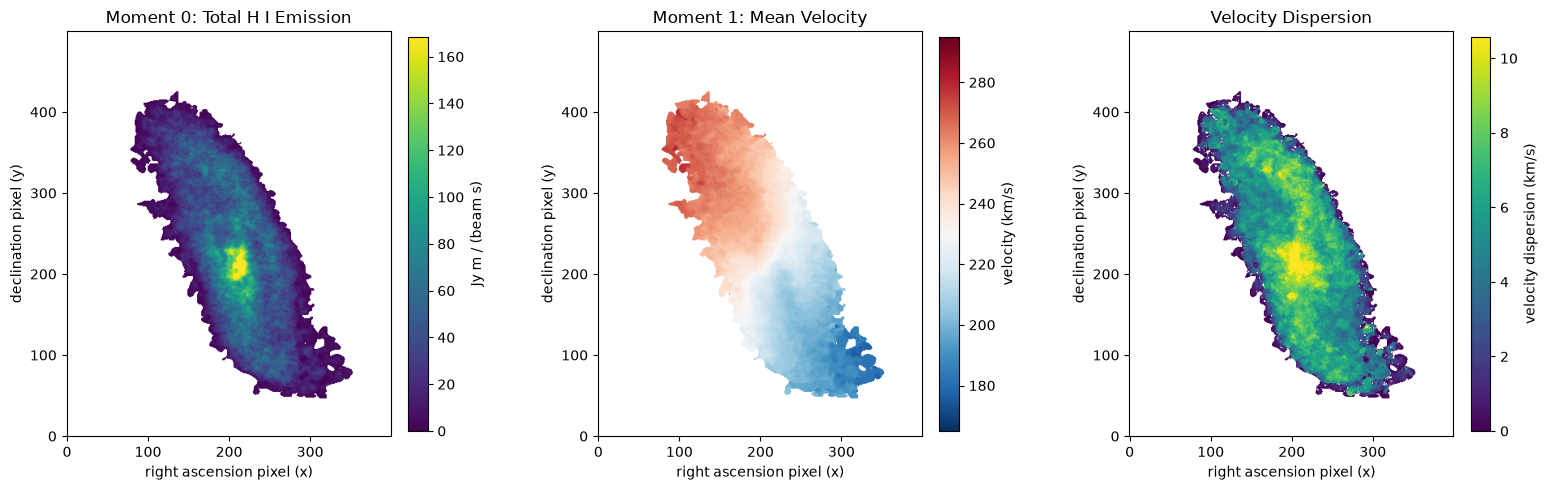

In [23]:
#plot moment maps and dispersion data
fig, axes = plt.subplots(1, 3, figsize=(16,5))

for a in axes:
    a.set_xlabel("right ascension pixel (x)")
    a.set_ylabel("declination pixel (y)")

#moment 0
momentMap0 = axes[0].imshow(moment0Data, origin='lower', cmap='viridis', vmin=0, vmax=np.nanpercentile(moment0Data, 99.5))
axes[0].set_title("Moment 0: Total H I Emission")
plt.colorbar(momentMap0, ax=axes[0], label=str(moment0.unit), fraction=0.046, pad=0.04)

#moment 1
momentMap1 = axes[1].imshow(moment1Data, origin='lower', cmap='RdBu_r', vmin=165, vmax=295)
axes[1].set_title("Moment 1: Mean Velocity")
plt.colorbar(momentMap1, ax=axes[1], label="velocity (km/s)", fraction=0.046, pad=0.04)

#velocity dispersion
velocityDisMap = axes[2].imshow(dispersionData, origin='lower', cmap='viridis', vmin=0, vmax=np.nanpercentile(dispersionData, 99))
axes[2].set_title("Velocity Dispersion")
plt.colorbar(velocityDisMap, ax=axes[2], label="velocity dispersion (km/s)", fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

### 2.4.2 Masked global H I spectrum

The cube values are in Jy beam$^{-1}$. Summing all of tbe retained image pixels in each channel would count a beam multiple times so the sum is / by the number of pixels per original beam.

In [24]:
# calcullate how many image pixels fit inside the original radio beam 
pixelScales = (proj_plane_pixel_scales(cubeVelocityCrop.wcs.celestial) * u.deg)

pixelArea = abs(pixelScales[0] * pixelScales[1])
beamArea = cubeVelocityCrop.beam.sr.to(u.deg**2)

pixelsPerBeamOriginal = (beamArea / pixelArea).decompose().value

# sum emission in each channel
channelSums = finalMaskedCube.sum(axis=(1, 2),how="slice")

# convert  summed Jy/beam pixels into total flux density in Jy
spectrum = (channelSums.value / pixelsPerBeamOriginal) * u.Jy

velocities = finalMaskedCube.spectral_axis.to_value(u.km / u.s)

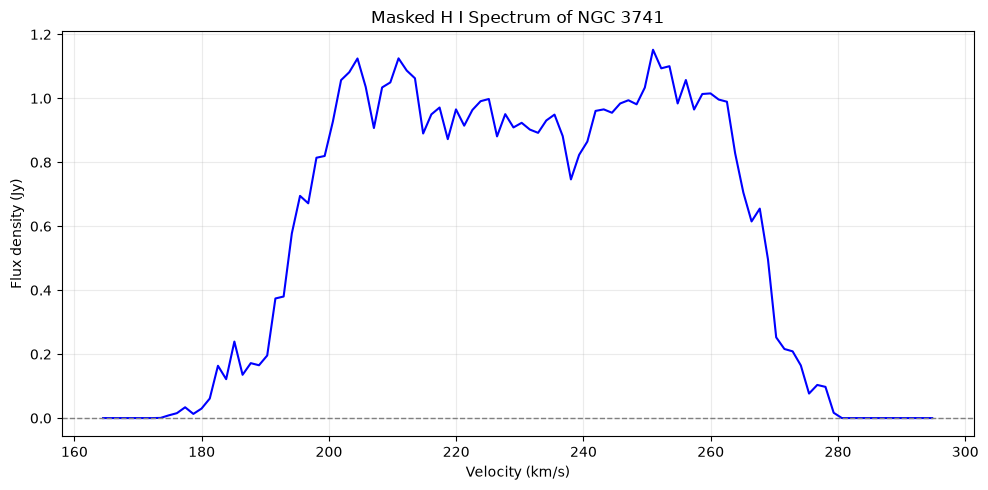

In [25]:
plt.figure(figsize=(10, 5))

plt.plot(
    velocities,
    spectrum.value,
    color="blue",
    linewidth=1.5
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Velocity (km/s)")
plt.ylabel("Flux density (Jy)")
plt.title("Masked H I Spectrum of NGC 3741")
plt.grid(alpha=0.25)

plt.tight_layout()
plt.show()

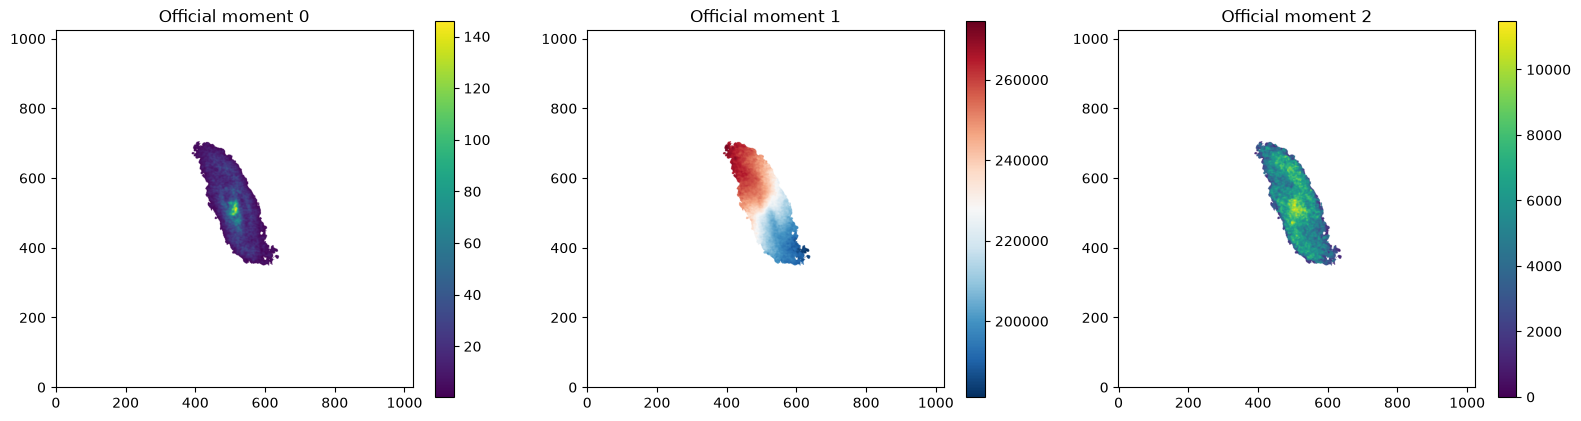

In [26]:
#display official moment maps from vla-angst survey page
from astropy.io import fits

officialMomentMaps = ["VLA-ANGST_HI_NGC3741-nat-Mom0.fits.gz","VLA-ANGST_HI_NGC3741-nat-Mom1.fits.gz","VLA-ANGST_HI_NGC3741-nat-Mom2.fits.gz"]
titles = ["Official moment 0", "Official moment 1", "Official moment 2"]
cmaps = ['viridis', 'RdBu_r', 'viridis']

fig, axes = plt.subplots(1, 3, figsize=(16,5))

for ax, file, title, cmap in zip(axes, officialMomentMaps, titles, cmaps):
    data = np.squeeze(fits.getdata(file))
    image = ax.imshow(data, origin='lower', cmap=cmap)
    ax.set_title(title)
    fig.colorbar(image, ax=ax, shrink=0.8)

plt.tight_layout()
plt.show()

### Comparison observations
Comparing the moment maps created in this notebook to the official moment maps from the VLA-ANGST survey page, I notice that the general countour/shape of the H I emission is quite similar. The official moment maps have cleaner edges, owing to differences in data wrangling and masking techniques. The grown-to-connected-seed method used in this notebook may have contributed to the additional inclusion of faint emission in the mask's edges. Nevertheless, I am quite happy with the results.

## Save final mask and masked FITS cube
After making minor adjustments to the masked cube, I export:

- `NGC3741_masked_cube.fits`
- `NGC3741_emission_mask.fits`
- `NGC3741_moment0.fits`
- `NGC3741_moment1.fits`
- `NGC3741_velocity_dispersion.fits`

In [27]:
outputFolder = Path("outputs")
outputFolder.mkdir(exist_ok=True)

assert finalMask.shape == cubeVelocityCrop.shape

finalMaskedCube.write(outputFolder / "NGC3741_masked_cube.fits", overwrite=True)

maskHeader = cubeVelocityCrop.header.copy()
maskHeader["BUNIT"] = "1"
fits.PrimaryHDU(data=finalMask.astype(np.uint8), header=maskHeader).writeto(outputFolder / "NGC3741_emission_mask.fits", overwrite=True)

moment0.write(outputFolder / "NGC3741_moment0.fits", overwrite=True)

moment1.write(outputFolder / "NGC3741_moment1.fits", overwrite=True)

velocityDispersion.write(outputFolder / "NGC3741_velocity_dispersion.fits", overwrite=True)

## Conclusion

The data analysis crops NGC 3741 in position and velocity and detects coherent emission in a spatially and spectrally smoothed copy of the data. Independently measured channel-wise RMS of the smoothed cube is used as the base of the detection thresholds. A 6σ seed mask is grown through connected 5σ voxels, after components smaller than one smoothed beam across three channels are removed. The resulting mask is applied to the original-resolution cropped cube, and moment maps plus a global spectrum are created before exporting them as outputs. 